In [1]:
"""Fit three HH conductance scales from 32 parallel initial points."""

import os
import sys
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "5"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

candidates = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next(
    (
        path
        for base in candidates
        for path in (base, base / "braincell")
        if (path / "pyproject.toml").is_file() and (path / "braincell").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the BrainCell repository root.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dataclasses import dataclass

import brainstate
import braintools
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np

import braincell
from braincell.filter import AllRegion, RootLocation
from examples.optim.parameter_fitting.diagnostics import (
    BestArchives,
    DiagnosticConfig,
    TrainingHistory,
    capture_state,
    capture_update,
    evaluate_voltage_protocols,
    extract_best_archives,
    finalize_history,
    format_summary,
    plot_diagnostics,
    save_artifacts,
    summarize_history,
    voltage_mse_objective,
)

In [2]:
DT = 0.025 * u.ms
DURATION = 50.0 * u.ms
NUM_STARTS = 32
NUM_EPOCHS = 100
LEARNING_RATE = 0.02
RANDOM_SEED = 123

CHANNEL_NAMES = ("leak", "na", "k")
TARGET_SCALES = (1.2, 0.85, 1.25)
INITIAL_SCALE_RANGE = (0.5, 1.5)
SCALE_BOUNDS = (0.1, 2.0)

In [3]:

@dataclass(frozen=True)
class TrainingResult:
    times_ms: object
    target_voltage_mv: object
    fitted_voltage_mv: object
    loss_history: object
    factor_history: object
    best_index: int
    target_spike_count: int
    diagnostics: TrainingHistory
    archives: BestArchives
    diagnostic_summary: dict[str, object]


def build_hh_cell(population_size: int, conductance_scales=TARGET_SCALES) -> braincell.Cell:
    leak_scale, sodium_scale, potassium_scale = conductance_scales
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[10.0, 10.0] * u.um,
        type="soma",
    )
    cell = braincell.Cell(
        braincell.Morphology.from_root(soma, name="soma"),
        cv_policy=braincell.CVPerBranch(),
        pop_size=(population_size,),
        V_init=-65.0 * u.mV,
        solver="staggered",
    )
    cell.paint(
        AllRegion(),
        braincell.mech.CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * u.uF / u.cm**2,
            axial_resistivity=100.0 * u.ohm * u.cm,
        ),
        braincell.mech.Ion("SodiumFixed", E=50.0 * u.mV),
        braincell.mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
        braincell.mech.Channel("IL", name="leak", g_max=0.1 * leak_scale * u.mS / u.cm**2),
        braincell.mech.Channel("Na_HH1952", name="na", g_max=120.0 * sodium_scale * u.mS / u.cm**2),
        braincell.mech.Channel("K_HH1952", name="k", g_max=10.0 * potassium_scale * u.mS / u.cm**2),
    )
    cell.place(
        RootLocation(0.5),
        braincell.mech.CurrentClamp(
            delay=5.0 * u.ms,
            durations=40.0 * u.ms,
            amplitudes=0.05 * u.nA,
        ),
    )
    cell.soma.record("v", braincell.observe.state("v"))
    return cell


def simulate(cell: braincell.Cell, *, dt=DT, duration=DURATION):
    cell.reset_state()
    result = cell.run(dt=dt, duration=duration)
    return result.samples["v"].values

In [4]:

def run_experiment(
    *,
    num_starts: int = NUM_STARTS,
    num_epochs: int = NUM_EPOCHS,
    dt=DT,
    duration=DURATION,
    seed: int = RANDOM_SEED,
    log_every: int | None = 10,
    artifact_dir=None,
    diagnostic_config: DiagnosticConfig = DiagnosticConfig(),
) -> TrainingResult:
    if num_starts < 1:
        raise ValueError("num_starts must be at least one.")
    if num_epochs < 1:
        raise ValueError("num_epochs must be at least one.")
    if log_every is not None and (isinstance(log_every, bool) or not isinstance(log_every, int) or log_every < 1):
        raise ValueError("log_every must be a positive integer or None.")

    target_cell = build_hh_cell(1, TARGET_SCALES)
    target_cell.init_state()
    target_voltage_mv = simulate(target_cell, dt=dt, duration=duration).to_decimal(u.mV)[:, 0]
    target_spike_count = _count_spikes(target_voltage_mv)
    if target_spike_count < 1:
        raise RuntimeError("The target protocol must produce at least one upward 0 mV crossing.")

    candidate_cell = build_hh_cell(num_starts, (1.0, 1.0, 1.0))
    random = brainstate.random.RandomState(seed)
    for channel_name in CHANNEL_NAMES:
        initial = random.uniform(*INITIAL_SCALE_RANGE, size=(num_starts,))
        factor = brainstate.nn.Param(
            initial,
            t=brainstate.nn.SigmoidT(*SCALE_BOUNDS),
        )
        candidate_cell.channels[channel_name].trainable(
            g_max=braincell.trainable.scale(
                factor,
                group_by="population",
                name=f"{channel_name}.scale",
            )
        )

    candidate_cell.init_state()
    parameters = candidate_cell.trainables.parameters()
    parameter_states = parameters.states()
    optimizer = braintools.optim.Adam(lr=LEARNING_RATE)
    optimizer.register_trainable_weights(parameter_states)

    def current_factors():
        values = parameters.physical_values()
        return jnp.stack([values[f"{name}.scale"] for name in CHANNEL_NAMES])

    targets = {"step": target_voltage_mv[:, None]}

    def evaluate_prediction(prediction_mv):
        predictions = {"step": prediction_mv[:, :, None]}
        per_candidate, components = voltage_mse_objective(predictions, targets)
        metrics = evaluate_voltage_protocols(predictions, targets)
        return per_candidate, components, metrics

    def loss():
        prediction_mv = simulate(candidate_cell, dt=dt, duration=duration).to_decimal(u.mV)
        per_candidate, components, metrics = evaluate_prediction(prediction_mv)
        return jnp.sum(per_candidate), (per_candidate, components, metrics)

    gradient = brainstate.transform.grad(
        loss,
        grad_states=parameter_states,
        has_aux=True,
        return_value=True,
    )

    def train_step(epoch):
        gradients, _, (per_candidate, components, metrics) = gradient()
        state = capture_state(
            parameters,
            total_loss=per_candidate,
            components=components,
            metrics=metrics,
        )
        update = capture_update(gradients, learning_rate=LEARNING_RATE)
        factors = current_factors()
        if log_every is not None:
            should_log = ((epoch + 1) % log_every == 0) | (epoch + 1 == num_epochs)

            def report(_):
                best = jnp.argmin(per_candidate)
                jax.debug.print(
                    "epoch {epoch}/{total} | mean MSE {mean:.6f} | best MSE {minimum:.6f} | scales {scales}",
                    epoch=epoch + 1,
                    total=num_epochs,
                    mean=jnp.mean(per_candidate),
                    minimum=per_candidate[best],
                    scales=factors[:, best],
                    ordered=True,
                )

            jax.lax.cond(should_log, report, lambda _: None, operand=None)
        optimizer.update(gradients)
        return state, update

    states, updates = brainstate.transform.for_loop(train_step, jnp.arange(num_epochs))

    fitted_voltage_mv = simulate(candidate_cell, dt=dt, duration=duration).to_decimal(u.mV)
    final_losses, final_components, final_metrics = evaluate_prediction(fitted_voltage_mv)
    endpoint = capture_state(
        parameters,
        total_loss=final_losses,
        components=final_components,
        metrics=final_metrics,
    )
    parameter_bounds = {f"{name}.scale": SCALE_BOUNDS for name in CHANNEL_NAMES}
    diagnostics = finalize_history(states, endpoint, updates, bounds=parameter_bounds)
    archives = extract_best_archives(diagnostics)
    target_parameters = {f"{name}.scale": value for name, value in zip(CHANNEL_NAMES, TARGET_SCALES)}
    diagnostic_summary = summarize_history(
        diagnostics,
        archives=archives,
        target_parameters=target_parameters,
        config=diagnostic_config,
    )
    loss_history = diagnostics.losses["total"]
    factor_history = jnp.stack(
        [diagnostics.physical_values[f"{name}.scale"] for name in CHANNEL_NAMES],
        axis=1,
    )
    best_index = int(jnp.argmin(final_losses))

    step_ms = float(np.asarray(dt.to_decimal(u.ms)).reshape(()))
    times_ms = jnp.arange(target_voltage_mv.shape[0]) * step_ms
    result = TrainingResult(
        times_ms=times_ms,
        target_voltage_mv=target_voltage_mv,
        fitted_voltage_mv=fitted_voltage_mv[:, best_index],
        loss_history=loss_history,
        factor_history=factor_history,
        best_index=best_index,
        target_spike_count=target_spike_count,
        diagnostics=diagnostics,
        archives=archives,
        diagnostic_summary=diagnostic_summary,
    )
    if artifact_dir is not None:
        save_artifacts(
            artifact_dir,
            diagnostics,
            diagnostic_summary,
            metadata={
                "dt_ms": step_ms,
                "duration_ms": float(np.asarray(duration.to_decimal(u.ms)).reshape(())),
                "num_starts": num_starts,
                "num_epochs": num_epochs,
                "seed": seed,
                "solver": "staggered",
                "backend": jax.default_backend(),
                "jax_enable_x64": bool(jax.config.jax_enable_x64),
                "learning_rate": LEARNING_RATE,
                "initial_scale_range": INITIAL_SCALE_RANGE,
                "scale_bounds": SCALE_BOUNDS,
                "target_scales": TARGET_SCALES,
                "protocols": ["step"],
                "probes": ["soma.v"],
            },
            archives=archives,
        )
    return result

In [5]:
def plot_result(result: TrainingResult):
    import matplotlib.pyplot as plt

    times = np.asarray(result.times_ms)
    target = np.asarray(result.target_voltage_mv)
    fitted = np.asarray(result.fitted_voltage_mv)
    losses = np.asarray(result.loss_history)
    factors = np.asarray(result.factor_history)[:, :, result.best_index]
    epochs = np.arange(losses.shape[0])

    figure, axes = plt.subplots(3, 1, figsize=(10.0, 9.0), constrained_layout=True)
    voltage_axis, loss_axis, factor_axis = axes

    voltage_axis.plot(times, target, label="target")
    voltage_axis.plot(times, fitted, label="best fit")
    voltage_axis.set(xlabel="Time (ms)", ylabel="Voltage (mV)", title="Voltage trace")
    voltage_axis.legend(frameon=False)

    loss_axis.plot(epochs, losses, alpha=0.2)
    loss_axis.plot(epochs, losses.mean(axis=1), label="mean")
    loss_axis.plot(epochs, losses.min(axis=1), label="best")
    loss_axis.set_yscale("log")
    loss_axis.set(xlabel="Adam update", ylabel="MSE (mV squared)", title="Candidate losses")
    loss_axis.legend(frameon=False)

    labels = ("leak scale", "Na scale", "K scale")
    for index, (label, target_scale) in enumerate(zip(labels, TARGET_SCALES)):
        line = factor_axis.plot(epochs, factors[:, index], label=label)[0]
        factor_axis.axhline(target_scale, color=line.get_color(), linestyle="--", alpha=0.6)
    factor_axis.set(
        xlabel="Adam update",
        ylabel="Scale factor",
        title=f"Best candidate {result.best_index} (dashed lines are targets)",
    )
    factor_axis.set_ylim(SCALE_BOUNDS)
    factor_axis.legend(frameon=False, ncol=3)
    return figure


def _count_spikes(voltage_mv) -> int:
    values = np.asarray(voltage_mv)
    return int(np.sum((values[:-1] < 0.0) & (values[1:] >= 0.0)))

In [6]:
result = run_experiment()

epoch 10/100 | mean MSE 821.947144 | best MSE 9.382583 | scales [1.1987661 0.6973739 1.0259244]
epoch 20/100 | mean MSE 501.074310 | best MSE 5.589873 | scales [1.2842139 0.9561669 1.3344619]
epoch 30/100 | mean MSE 261.057709 | best MSE 3.306777 | scales [1.3129361 0.95072   1.3328686]
epoch 40/100 | mean MSE 117.851715 | best MSE 0.135213 | scales [1.1382673  0.83314586 1.2559816 ]
epoch 50/100 | mean MSE 37.279610 | best MSE 0.867613 | scales [1.1406007 0.8318764 1.258348 ]
epoch 60/100 | mean MSE 23.271877 | best MSE 0.915174 | scales [1.1367666 0.8364978 1.2546321]
epoch 70/100 | mean MSE 12.786242 | best MSE 0.543182 | scales [1.140898  0.8331979 1.2583467]
epoch 80/100 | mean MSE 10.130226 | best MSE 0.257530 | scales [1.1388888  0.83593374 1.2561594 ]
epoch 90/100 | mean MSE 8.755959 | best MSE 0.157843 | scales [1.1407492 0.8348707 1.2576014]
epoch 100/100 | mean MSE 8.182789 | best MSE 0.108794 | scales [1.1405329 0.8358727 1.2570461]


In [7]:
losses = np.asarray(result.loss_history)
final_factors = np.asarray(result.factor_history)[-1, :, result.best_index]
print(f"target spikes: {result.target_spike_count}")
print(f"mean MSE: {losses[0].mean():.6f} -> {losses[-1].mean():.6f} mV^2")
print(f"best MSE: {losses[0].min():.6f} -> {losses[-1].min():.6f} mV^2")
print(f"best scales: {final_factors}")
print(f"diagnostic counts: {result.diagnostic_summary['counts']}")

continuous_start = int(jnp.nanargmin(result.archives.continuous.losses["total"]))
print(
    "continuous archive: "
    f"start {continuous_start}, epoch {int(result.archives.continuous.epoch[continuous_start])}, "
    f"MSE {float(result.archives.continuous.losses['total'][continuous_start]):.6f}"
)
feasible_loss = np.asarray(result.archives.spike_feasible.losses["total"])
if np.asarray(result.archives.spike_feasible.valid).any():
    feasible_start = int(np.nanargmin(feasible_loss))
    print(
        "spike-feasible archive: "
        f"start {feasible_start}, epoch {int(result.archives.spike_feasible.epoch[feasible_start])}, "
        f"MSE {feasible_loss[feasible_start]:.6f}"
    )
else:
    print("spike-feasible archive: none")
print(format_summary(result.diagnostic_summary))

target spikes: 3
mean MSE: 1203.611084 -> 8.114389 mV^2
best MSE: 8.767759 -> 0.092253 mV^2
best scales: [1.1407206 0.8357678 1.2571883]
diagnostic counts: {'region_state/feasible': 32, 'optimization_state/improving': 31, 'optimization_state/slow-progress': 1, 'degraded_from_best': 5, 'near_bound': 0, 'parameter_success': 10, 'spike_feasible_archive': 32}
continuous archive: start 15, epoch 100, MSE 0.092253
spike-feasible archive: start 15, epoch 100, MSE 0.092253
start  initial      best     final  best@  feasible@  region       optimization  param_err
    0  729.765    44.439    44.439    100        100  feasible     improving         0.342
    1  742.247     9.882     9.882    100        100  feasible     improving         0.214
    2  1950.212    10.851    10.852     98         98  feasible     improving         0.153
    3  259.783    24.787    24.787    100        100  feasible     improving         0.249
    4  1598.717     4.723     4.968     94         94  feasible     improv

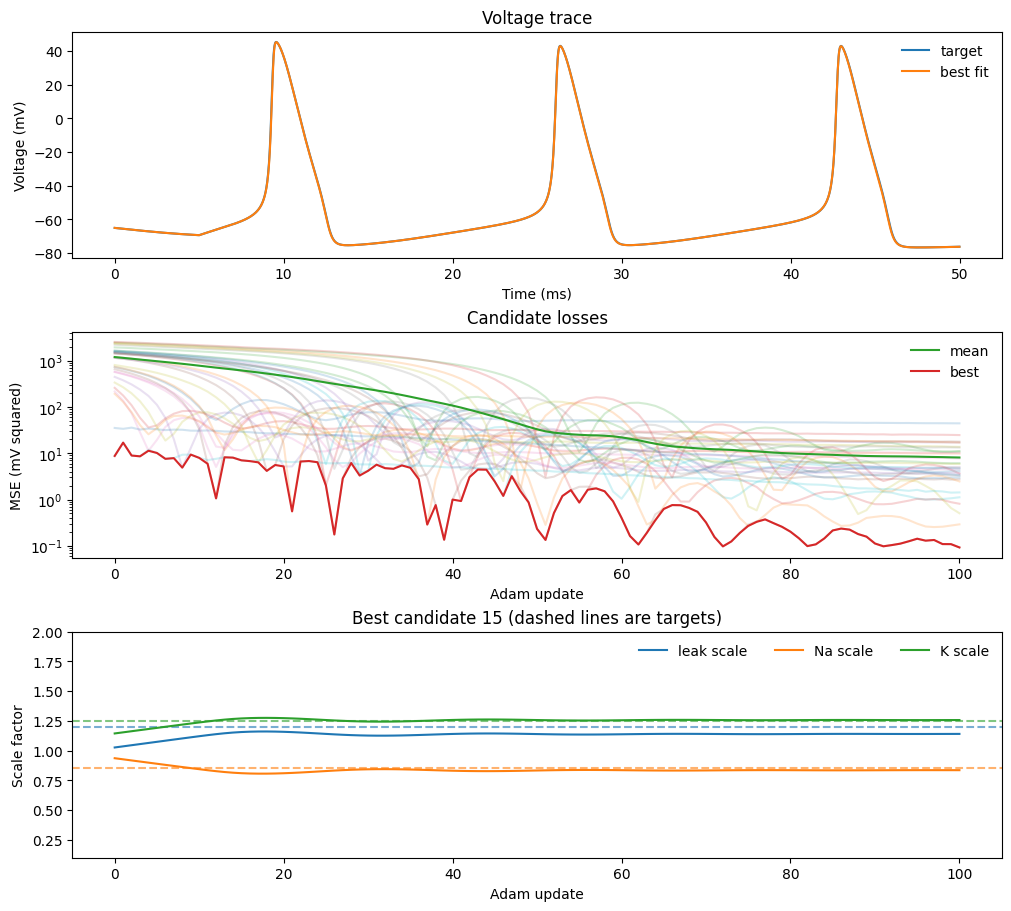

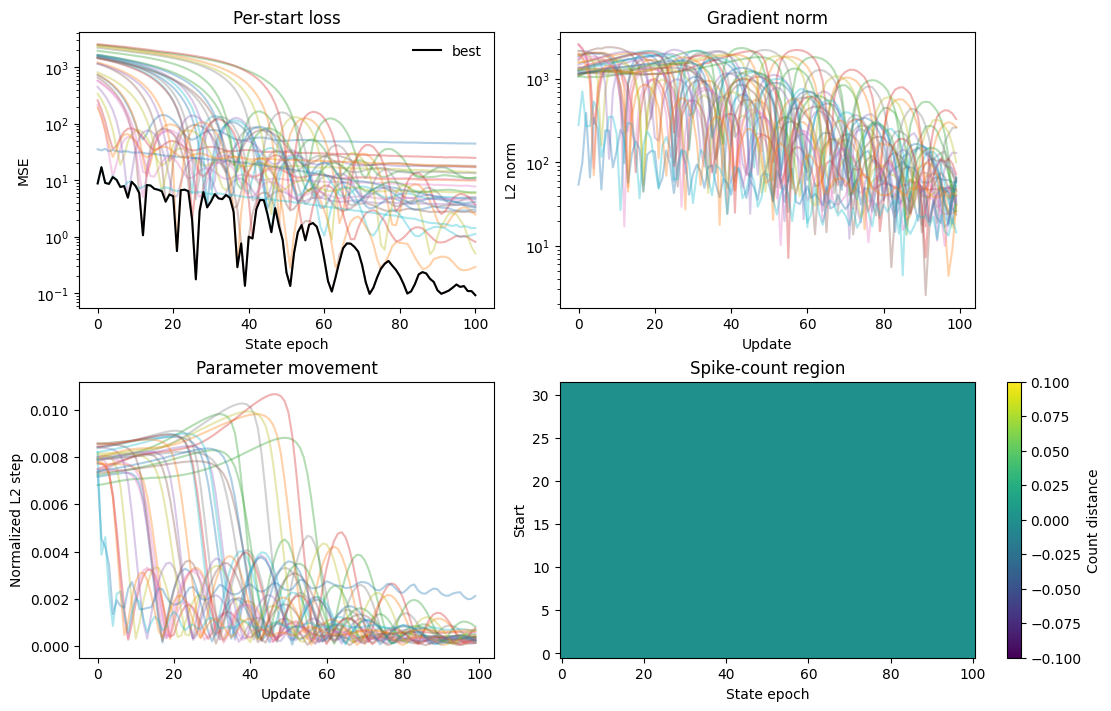

In [8]:
import matplotlib.pyplot as plt

plot_result(result)
plot_diagnostics(result.diagnostics)
plt.show()